
Labelstudio.Png


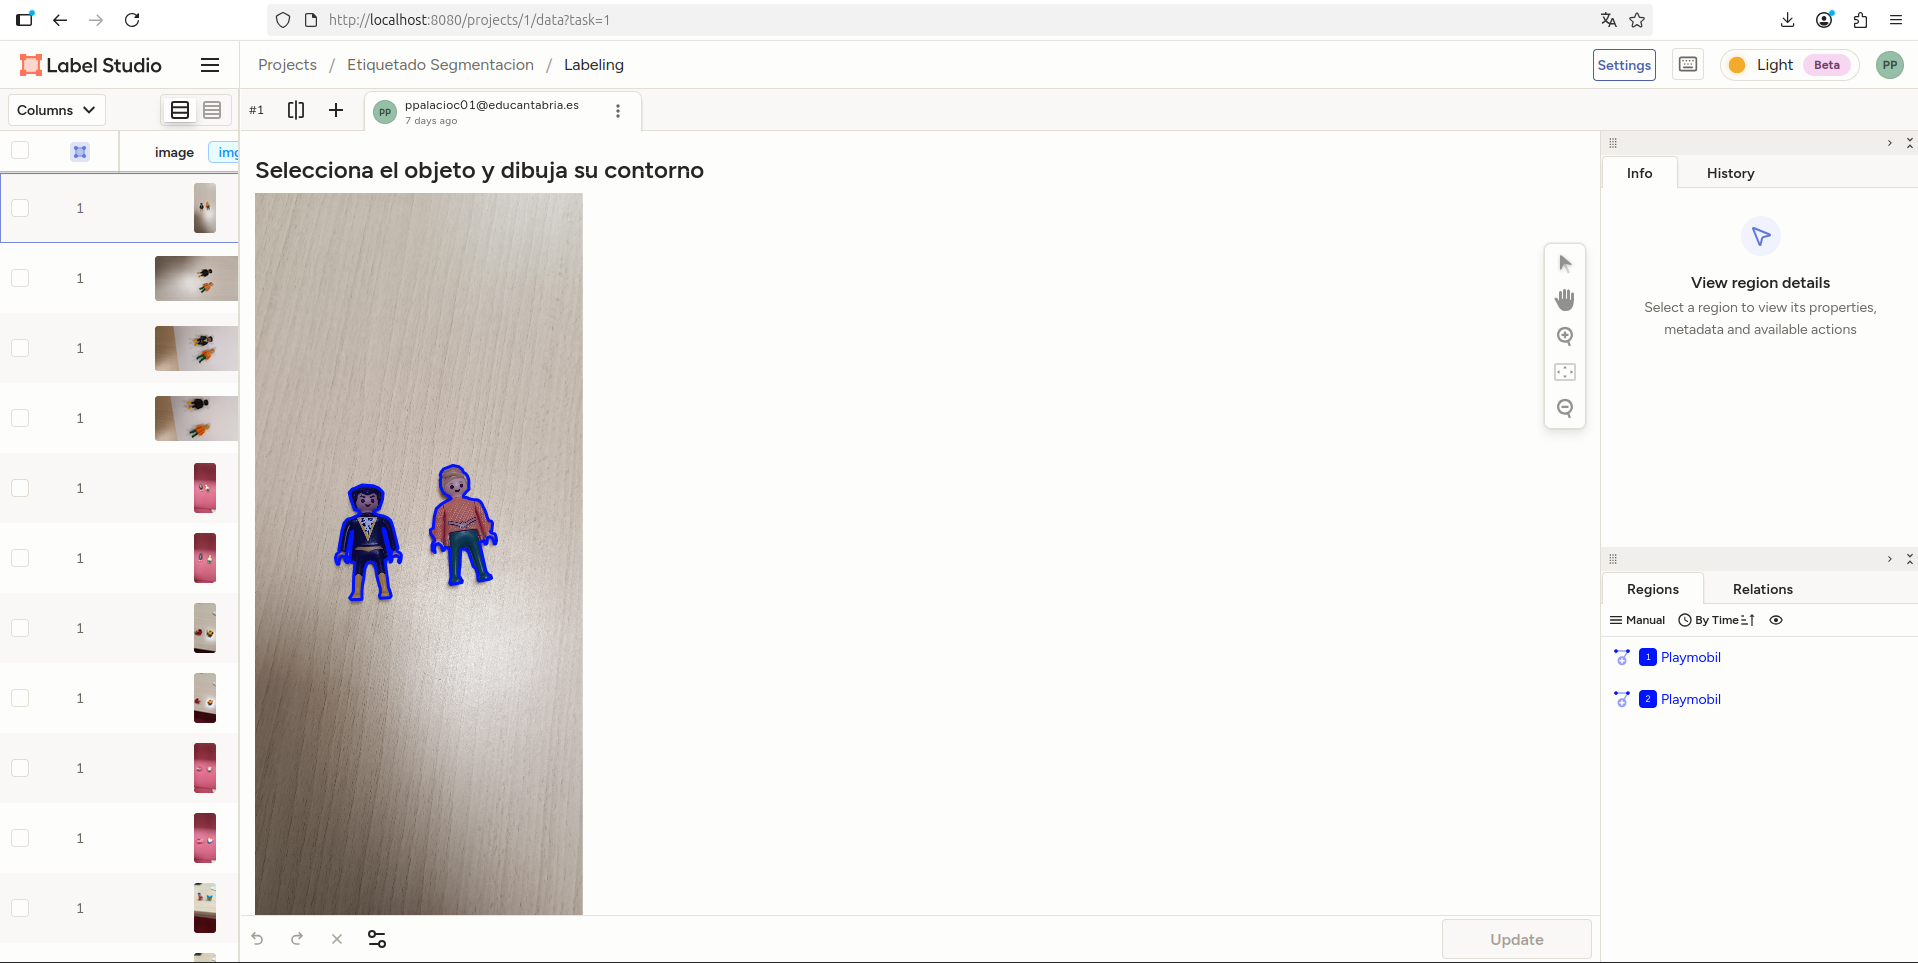

In [1]:

from IPython.display import Image, display
import os

results_path = "Capturas"

# Mostrar las gráficas generadas
graficas = ["LabelStudio.png"]

for grafica in graficas:
    ruta = os.path.join(results_path, grafica)
    if os.path.exists(ruta):
        print(f"\n{'='*50}")
        print(f"{grafica.replace('_', ' ').title()}")
        print('='*50)
        display(Image(filename=ruta))

In [ ]:
from ultralytics import YOLO

# Cargar un modelo de clasificación preentrenado
# yolo11n-cls.pt para velocidad o yolo11m-cls.pt para precisión

model = YOLO('yolo11m-cls.pt') 

# Entrenar el modelo
results = model.train(
 data="", # Ruta a la carpeta raíz del dataset descargado
 epochs=40, # Número de iteraciones
 imgsz=224, # Tamaño de la imagen
 device=0 # Usar GPU (si está disponible)
)

In [ ]:
# Visualizar las Métricas de Entrenamiento

from IPython.display import Image, display
import os

print("RESULTADOS DEL ENTRENAMIENTO\n")

# Ruta a los resultados
results_path = "runs/classify/train"

# Mostrar las gráficas generadas
graficas = ['results.png', 'confusion_matrix.png', 'confusion_matrix_normalized.png']

for grafica in graficas:
    ruta = os.path.join(results_path, grafica)
    if os.path.exists(ruta):
        print(f"\n{'='*50}")
        print(f"{grafica.replace('_', ' ').title()}")
        print('='*50)
        display(Image(filename=ruta))

In [ ]:
# Pruebas con Imágenes Reales

import matplotlib.pyplot as plt
from PIL import Image as PILImage

# Lista de imágenes a probar
imagenes_prueba = [
    './ImagenesPrueba/bueno.jpeg',
    './ImagenesPrueba/maduro.jpeg',
    './ImagenesPrueba/normal.jpeg'
]

# Nombres de las clases (en el orden del modelo)
# overripe(sobremaduro/pasado) ripe(maduro) rotten(podrido) unripe(verde)
nombres_clases = ['overripe', 'ripe', 'rotten', 'unripe']

print("PRUEBAS CON IMÁGENES NUEVAS\n")

for i, img_path in enumerate(imagenes_prueba, 1):
    print(f"\n{'='*60}")
    print(f"IMAGEN {i}: {img_path}")
    print('='*60)
    
    # Realizar predicción
    results = model(img_path)
    
    # Obtener las probabilidades
    probs = results[0].probs.data.cpu().numpy()
    
    # Clase predicha
    clase_predicha = nombres_clases[probs.argmax()]
    confianza = probs.max() * 100
    
    print(f"\nPredicción: {clase_predicha.upper()}")
    print(f"Confianza: {confianza:.2f}%")
    print(f"\nProbabilidades por clase:")
    for nombre, prob in zip(nombres_clases, probs):
        print(f"  - {nombre}: {prob*100:.2f}%")
    
    # Mostrar la imagen
    plt.figure(figsize=(8, 6))
    img = PILImage.open(img_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicción: {clase_predicha} ({confianza:.1f}%)", 
              fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    

In [ ]:
from ultralytics import YOLO
import cv2
import os

def main():
    # 1. Cargar el modelo base pre-entrenado
    # 'n' es nano (rápido), 'seg' habilita la segmentación (máscaras)
    print("Cargando modelo...")
    model = YOLO("yolo11n-seg.pt")

    # 2. Entrenar el modelo (Afinar)
    # Asegúrate de que la ruta al data.yaml sea absoluta o correcta relativa
    print("Iniciando entrenamiento...")
    results = model.train(
        data="content/datasets/dataset_muñecos",  # Ruta a tu dataset
        epochs=40,  # Reducido a 10 para la clase (para que dé tiempo)
        imgsz=640,  # Tamaño de imagen
        plots=True,  # Generar gráficas de pérdida
        device='cpu',  # Forzar CPU si no tienen CUDA configurado (opcional)
        project='clase_yolo',  # Carpeta donde se guardan resultados
        name='muñecos_run'  # Nombre del experimento
    )

    # 3. Cargar el modelo que acabamos de entrenar (el mejor resultado)
    # La ruta dependerá de dónde se creó la carpeta 'clase_yolo'
    best_weight_path = os.path.join('clase_yolo', 'agua_run', 'weights', 'best.pt')
    print(f"Cargando el modelo entrenado desde: {best_weight_path}")
    tuned_model = YOLO(best_weight_path)

    # 4. Inferencia (Predicción) en nuevas imágenes
    # Usamos una imagen de prueba del dataset
    test_img_path = "content/datasets/dataset_muñecos/images/val/imagen_1.jpg"  # CAMBIAR POR UNA IMAGEN REAL

    if os.path.exists(test_img_path):
        results = tuned_model(test_img_path)

        # 5. Mostrar resultados
        for result in results:
            # Guardar la imagen en disco
            result.save(filename="resultado_prediccion.jpg")

            # Mostrar en una ventana emergente (típico de OpenCV)
            im_array = result.plot()  # plot() dibuja las máscaras y cajas en la imagen
            cv2.imshow("Deteccion de Agua", im_array)
            cv2.waitKey(0)  # Esperar a que se pulse una tecla
            cv2.destroyAllWindows()

    else:
        print(f"No se encontró la imagen de prueba: {test_img_path}")


if __name__ == '__main__':
    # En Windows es necesario proteger el entry point para multiproceso
    main()


Cargando modelo...
Iniciando entrenamiento...
New https://pypi.org/project/ultralytics/8.4.6 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.235 🚀 Python-3.10.19 torch-2.9.1+cu128 CPU (13th Gen Intel Core i7-13700F)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=content/datasets/dataset_muñecos, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=1.0, m

RuntimeError: Dataset 'content/datasets/dataset_muñecos' error ❌ [Errno 21] Is a directory: 'content/datasets/dataset_muñecos'